In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Datasets/Cleaned Datasets/Cleaned Algerian Forest Dataset.csv')

In [3]:
df.drop(['day', 'month', 'year'],axis=1, inplace=True)

In [4]:
df['Classes'] = df['Classes'].str.strip() 

In [5]:
df['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

In [6]:
df['Classes'] = np.where(df['Classes'] == 'not fire',0,1)


In [7]:
df.head()
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [8]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [9]:
X = df.drop('FWI', axis=1)
y = df['FWI']

In [10]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [11]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [14]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
115,29,65,19,0.6,68.3,5.5,15.2,1.5,5.8,0,0
207,33,37,16,0.0,92.2,61.3,167.2,13.1,64.0,1,1
158,38,43,13,0.5,85.0,13.0,35.4,4.1,13.7,1,1
132,31,42,21,0.0,90.6,18.2,30.5,13.4,18.0,1,1
84,34,64,14,0.0,88.9,40.5,171.3,9.0,50.9,1,0
...,...,...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,7.3,0.2,1.4,0,0
14,28,80,17,3.1,49.4,3.0,7.4,0.4,3.0,0,0
92,25,76,17,7.2,46.0,1.3,7.5,0.2,1.8,0,0
179,34,59,16,0.0,88.1,19.5,47.2,7.4,19.5,1,1


In [15]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,0.539642,0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,-0.454926,-0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,-0.075322,-0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,-0.378585,-0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,0.786012,0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,0.606775,0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,0.538893,-0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,0.740072,0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,0.602102,0.090326
Classes,0.539642,-0.454926,-0.075322,-0.378585,0.786012,0.606775,0.538893,0.740072,0.602102,1.000000,0.196276


<Axes: >

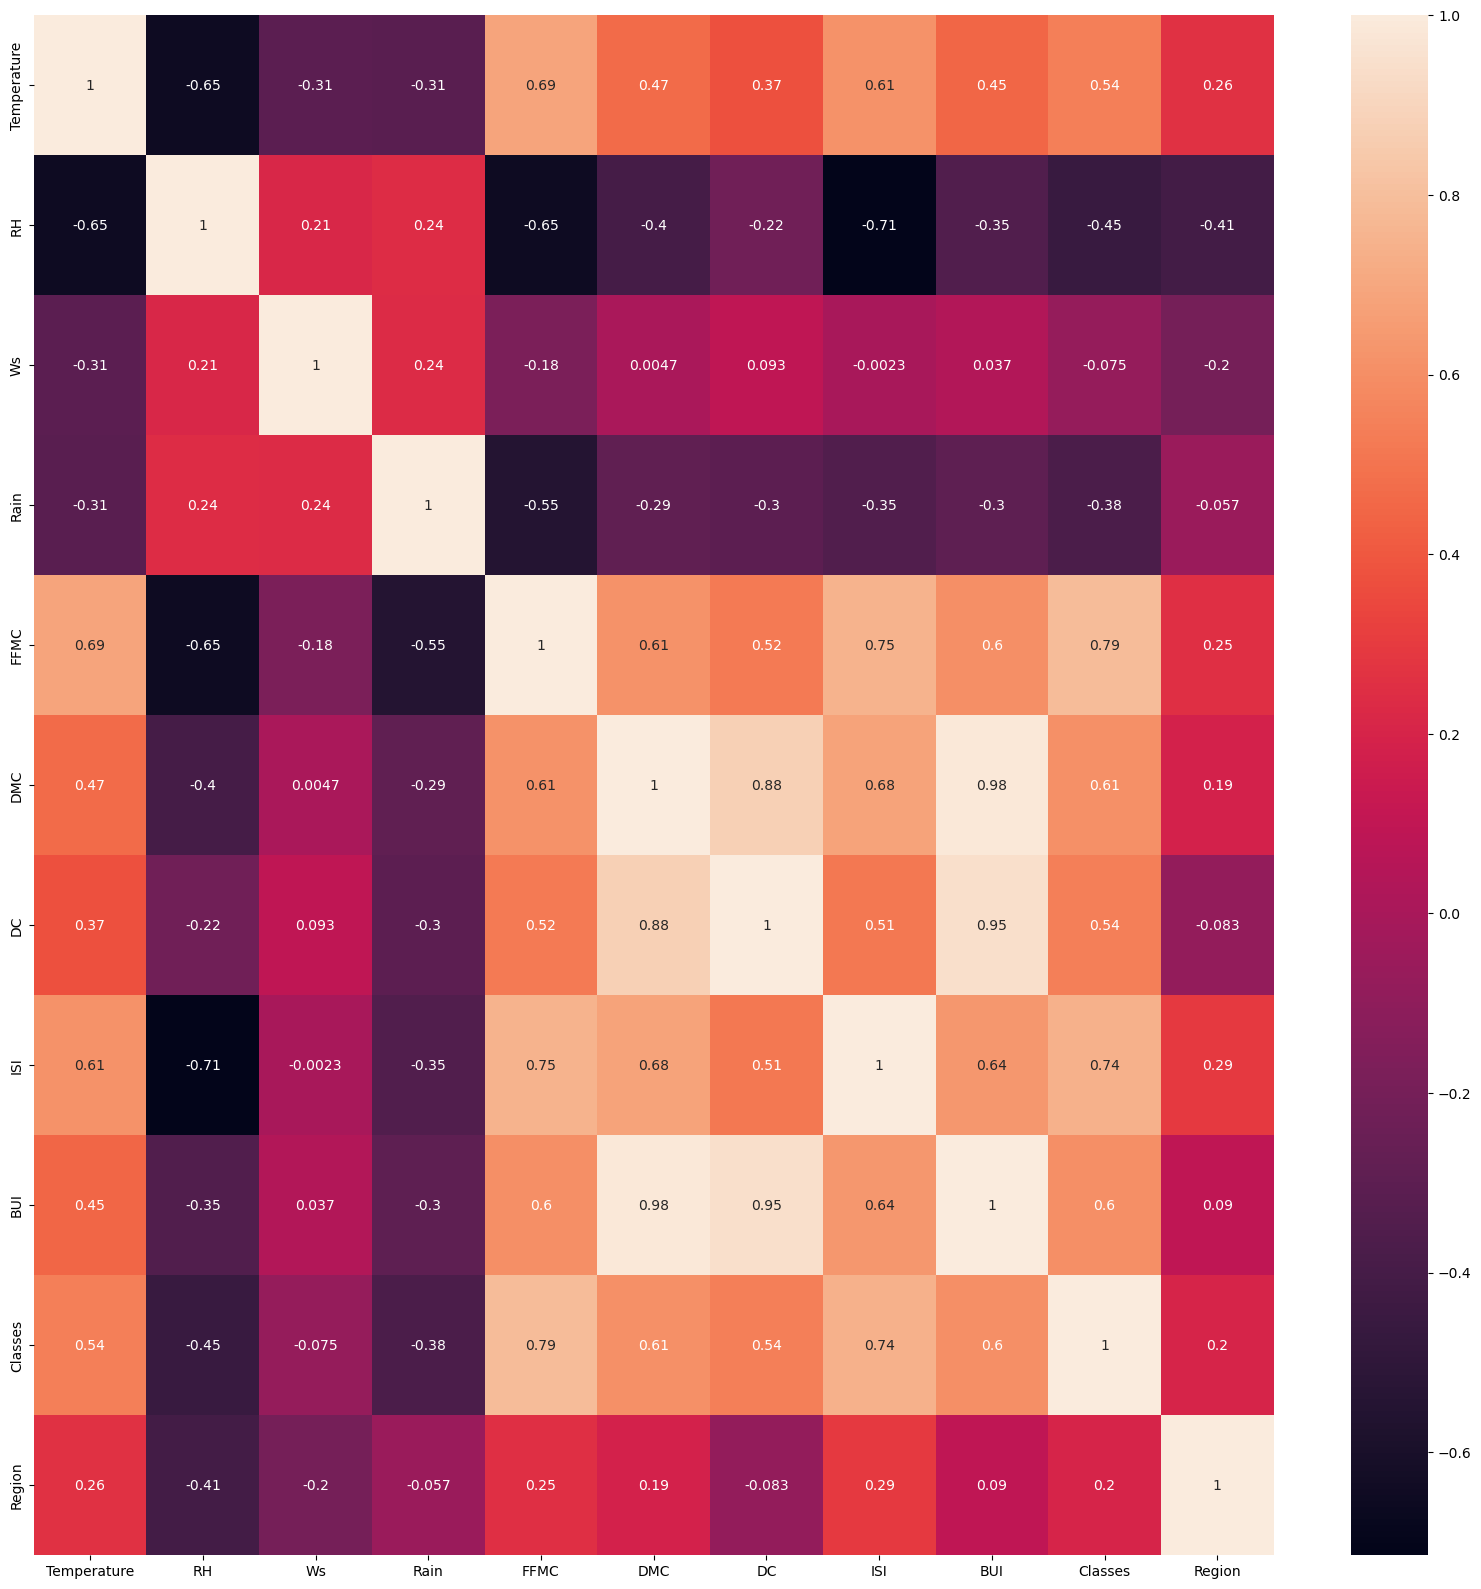

In [16]:
### Feature Selection
plt.figure(figsize=(20,20))
sns.heatmap(X_train.corr(), annot=True)

In [17]:
len(X_train.corr())

11

In [18]:
def threshold_corr(dataset, threshold):
    corr_columns = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix)):
        for j in range (i):
            if abs(corr_matrix.iloc[i][j])>threshold:
                colname = corr_matrix.columns[i]
                corr_columns.add(colname)
    return corr_columns

corr_features_to_drop = threshold_corr(X_train, 0.85)




C:\Users\Ekangsh\AppData\Local\Temp\ipykernel_25976\2845332801.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if abs(corr_matrix.iloc[i][j])>threshold:


In [19]:
corr_features_to_drop

{'BUI', 'DC'}

In [20]:
X_train.drop(corr_features_to_drop, axis=1, inplace=True)
X_test.drop(corr_features_to_drop, axis=1, inplace=True)

In [21]:
X_train.shape, X_test.shape

((194, 9), (49, 9))

In [22]:
### Standardisation
from sklearn.preprocessing import StandardScaler

In [23]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
115,29,65,19,0.6,68.3,5.5,1.5,0,0
207,33,37,16,0.0,92.2,61.3,13.1,1,1
158,38,43,13,0.5,85.0,13.0,4.1,1,1
132,31,42,21,0.0,90.6,18.2,13.4,1,1
84,34,64,14,0.0,88.9,40.5,9.0,1,0
...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,0.2,0,0
14,28,80,17,3.1,49.4,3.0,0.4,0,0
92,25,76,17,7.2,46.0,1.3,0.2,0,0
179,34,59,16,0.0,88.1,19.5,7.4,1,1


In [24]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

<Axes: title={'center': 'After Scaling'}>

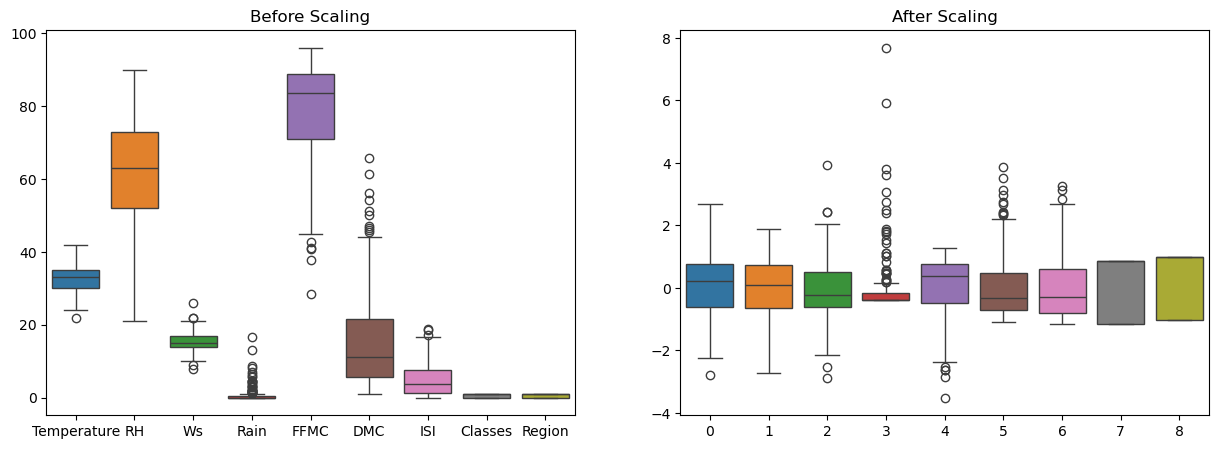

In [25]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.title("Before Scaling")
sns.boxplot(data = X_train)
plt.subplot(1, 2, 2)
plt.title("After Scaling")
sns.boxplot(X_train_scaled)

### Linear Regression

Mean Absolute Error  0.5049978694165665
R2 score 0.9805895859259883


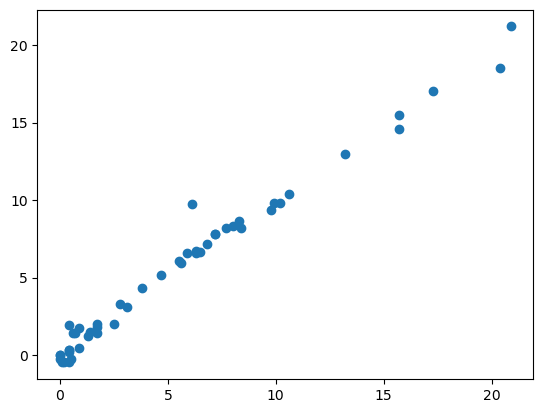

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred)
print('Mean Absolute Error ', mae)
print('R2 score', r2)


### Lasso Regression

Mean Absolute Error  1.0093958923873403
R2 score 0.9430507350726564


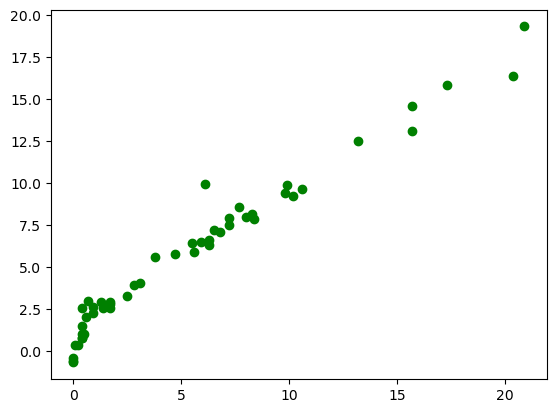

In [30]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='g')
print('Mean Absolute Error ', mae)
print('R2 score', r2)

### LassoCV Regression

Mean Absolute Error  0.5466552743862259
Mean Squared Error  0.6420515163336796
R2 score 0.9788160687773405


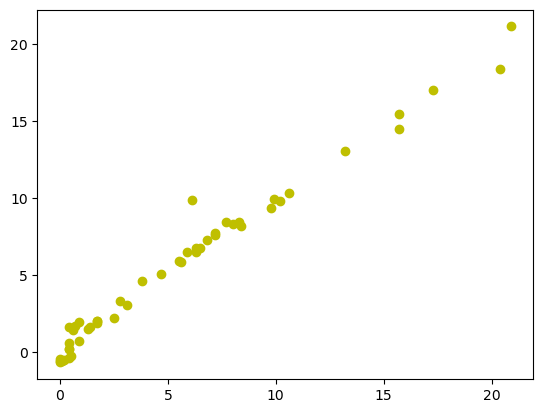

In [53]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lassocv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5)
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='y')
print('Mean Absolute Error ', mae)
print('Mean Squared Error ', mse)
print('R2 score', r2)

In [57]:
print('Alpha chosen by model ',lassocv.alpha_)
msevals = pd.DataFrame(lassocv.mse_path_) ### MSE for each cross validation
msevals

Alpha chosen by model  0.03906939937054617


,0,1,2,3,4
0,68.589350,64.286502,50.625130,79.114741,43.510090
1,68.589350,64.286502,50.625130,79.114741,43.510090
2,68.589350,64.286502,50.625130,79.114741,43.510090
3,68.589350,64.286502,50.625130,79.114741,43.510090
4,68.589350,64.286502,50.625130,79.114741,43.510090
5,68.589350,64.286502,50.625130,79.114741,43.510090
6,68.589350,64.286502,50.625130,79.114741,43.510090
7,68.589350,64.286502,50.625130,79.114741,43.510090
8,68.589350,64.286502,50.625130,79.114741,43.510090
9,68.589350,64.286502,50.625130,79.114741,43.510090


In [58]:
# Find which row index corresponds to the chosen alpha
alphas_sorted = lassocv.alphas_  # actual grid used (sklearn sorts descending!)
best_idx = np.argmin(np.abs(alphas_sorted - lassocv.alpha_))
print("Alpha at that row:", alphas_sorted[best_idx])
print("MSE across folds at that row:", lassocv.mse_path_[best_idx])
print("Mean CV MSE at best alpha:", lassocv.mse_path_[best_idx].mean())

Alpha at that row: 0.03906939937054617
MSE across folds at that row: [0.86481514 1.53140474 6.96605941 1.76739142 0.67876371]
Mean CV MSE at best alpha: 2.361686881755066


### Ridge Regresssion

Mean Absolute Error  0.519204832584476
R2 score 0.9801058063273601


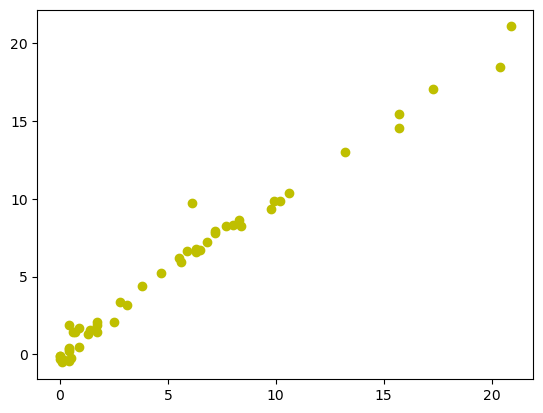

In [31]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='y')
print('Mean Absolute Error ', mae)
print('R2 score', r2)

### RIdgeCV Regression

Mean Absolute Error  0.5902965994012812
Mean Squared Error  0.6838413665423426
R2 score 0.9774372490251799


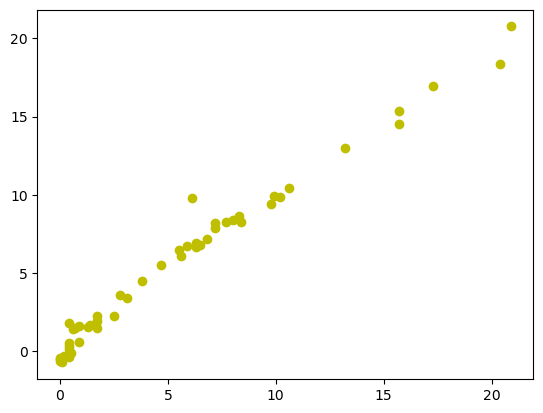

In [59]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
ridgecv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='y')
print('Mean Absolute Error ', mae)
print('Mean Squared Error ', mse)
print('R2 score', r2)

In [ ]:
print('Alpha Chosen by model ', ridgecv.alpha_)

Alpha Chosen by model  4.714866363457395


array([ 2.43368887e-03, -3.01266125e-01,  6.10452584e-02, -3.03433488e-02,
       -6.58117092e-01,  3.74126673e+00,  4.51054438e+00,  5.02631366e-01,
       -3.72633872e-01])

### ElasticNet Regression

Mean Absolute Error  1.6834416340136709
R2 score 0.8676961352267808


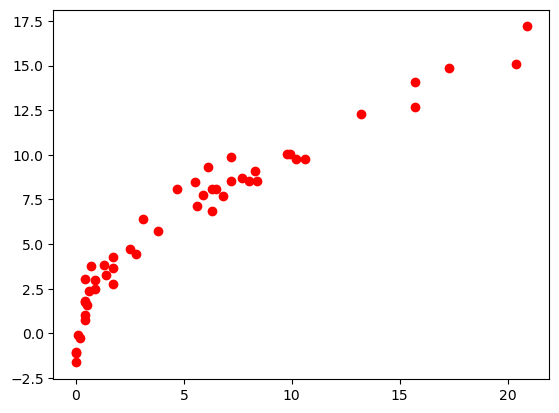

In [35]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='r')
print('Mean Absolute Error ', mae)
print('R2 score', r2)

### ElasticNETCV Regression

Mean Absolute Error  0.572671695356549
Mean Squared Error  0.6661128376154216
R2 score 0.9780221864140227


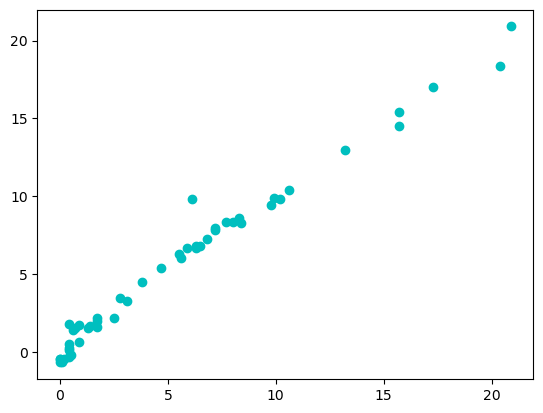

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
elascv = ElasticNetCV(alphas=np.logspace(-3, 3, 50), cv=5)
elascv.fit(X_train_scaled, y_train)
y_pred = elascv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.scatter(y_test, y_pred, c='c')
print('Mean Absolute Error ', mae)
print('Mean Squared Error ', mse)
print('R2 score', r2)


In [68]:
print('Alpha Chosen by model ', elascv.alpha_)
elascv.coef_

Alpha Chosen by model  0.029470517025518096


array([-0.        , -0.190818  ,  0.02189811, -0.        , -0.59662392,
        3.74311021,  4.65605292,  0.39465069, -0.35939282])